In [1]:
import numpy as np # Linear algebra
import pandas as pd # data processing
pd.set_option('display.max_columns', None)
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report


In [3]:
data = pd.read_csv('startup data.csv')

In [5]:
data.head()

,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,founded_at,closed_at,first_funding_at,last_funding_at,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,state_code.1,is_CA,is_NY,is_MA,is_TX,is_otherstate,category_code,is_software,is_web,is_mobile,is_enterprise,is_advertising,is_gamesvideo,is_ecommerce,is_biotech,is_consulting,is_othercategory,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,1/1/2007,NaN,4/1/2009,1/1/2010,2.2493,3.0027,4.6685,6.7041,3,3,375000,3,CA,1,0,0,0,0,music,0,0,0,0,0,0,0,0,0,1,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,1/1/2000,NaN,2/14/2005,12/28/2009,5.1260,9.9973,7.0055,7.0055,9,4,40100000,1,CA,1,0,0,0,0,enterprise,0,0,0,1,0,0,0,0,0,0,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,3/18/2009,NaN,3/30/2010,3/30/2010,1.0329,1.0329,1.4575,2.2055,5,1,2600000,2,CA,1,0,0,0,0,web,0,1,0,0,0,0,0,0,0,0,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,1/1/2002,NaN,2/17/2005,4/25/2007,3.1315,5.3151,6.0027,6.0027,5,3,40000000,1,CA,1,0,0,0,0,software,1,0,0,0,0,0,0,0,0,0,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,8/1/2010,10/1/2012,8/1/2010,4/1/2012,0.0000,1.6685,0.0384,0.0384,2,2,1300000,1,CA,1,0,0,0,0,games_video,0,0,0,0,0,1,0,0,0,0,c:65806,1,1,0,0,0,0,1.0000,1,closed


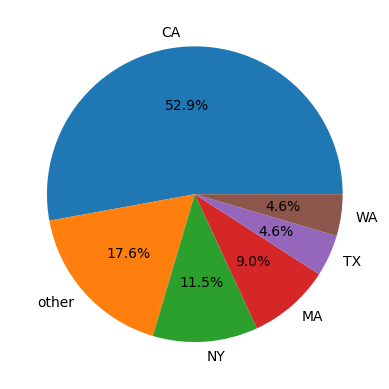

In [7]:
data['State'] = 'other'
data.loc[(data['state_code'] == 'CA'), 'State'] = 'CA'
data.loc[(data['state_code'] == 'NY'), 'State'] = 'NY'
data.loc[(data['state_code'] == 'MA'), 'State'] = 'MA'
data.loc[(data['state_code'] == 'TX'), 'State'] = 'TX'
data.loc[(data['state_code'] == 'WA'), 'State'] = 'WA'

state_count = data['State'].value_counts()
plt.pie(state_count, labels = state_count.index, autopct = '%1.1f%%')
plt.show()


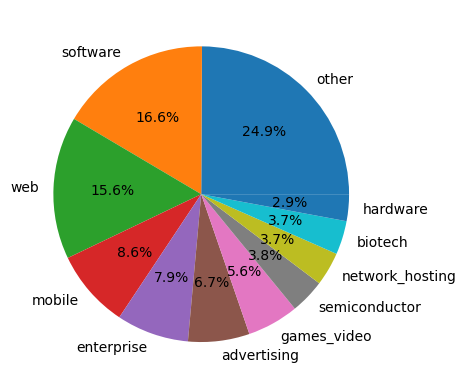

In [9]:
data['category'] = 'other'
data.loc[(data['category_code'] == 'software'), 'category'] = 'software'
data.loc[(data['category_code'] == 'web'), 'category'] = 'web'
data.loc[(data['category_code'] == 'mobile'), 'category'] = 'mobile'
data.loc[(data['category_code'] == 'enterprise'), 'category'] = 'enterprise'
data.loc[(data['category_code'] == 'advertising'), 'category'] = 'advertising'
data.loc[(data['category_code'] == 'games_video'), 'category'] = 'games_video'
data.loc[(data['category_code'] == 'semiconductor'), 'category'] = 'semiconductor'
data.loc[(data['category_code'] == 'network_hosting'), 'category'] = 'network_hosting'
data.loc[(data['category_code'] == 'biotech'), 'category'] = 'biotech'
data.loc[(data['category_code'] == 'hardware'), 'category'] = 'hardware'

category_count = data['category'].value_counts()
plt.pie(category_count, labels = category_count.index, autopct = '%1.1f%%')
plt.show()

Text(0.5, 1.0, 'Distribution of Status of the Startup')

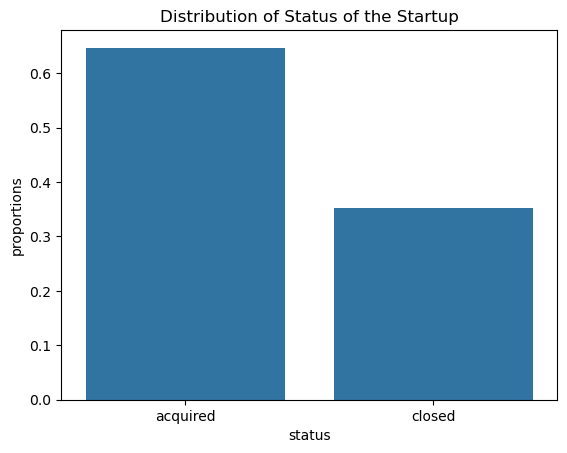

In [11]:
prop_df = data.groupby('status').size().reset_index(name = 'counts')
prop_df['proportions'] = prop_df['counts'] / prop_df['counts'].sum()

sns.barplot(data = prop_df, x = 'status', y = 'proportions')
plt.title('Distribution of Status of the Startup')

Text(0.5, 1.0, 'State vs Status')

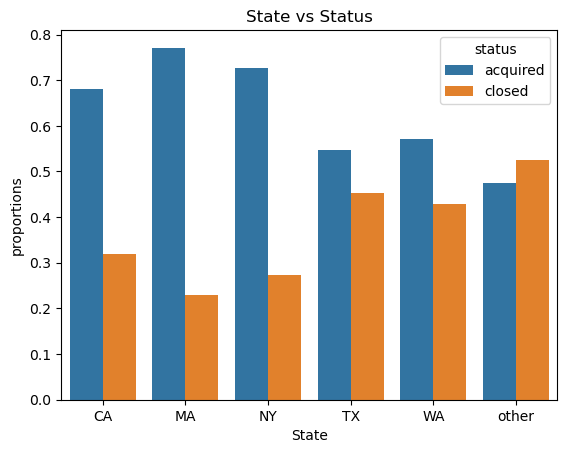

In [15]:
prop_df = data.groupby(['State','status'], group_keys=True).size().reset_index(name='count')
prop_df['proportions'] = prop_df['count'] / prop_df.groupby('State')['count'].transform('sum')

sns.barplot(data=prop_df, x='State', y='proportions', hue='status')
plt.title('State vs Status')


<Axes: xlabel='category', ylabel='proportions'>

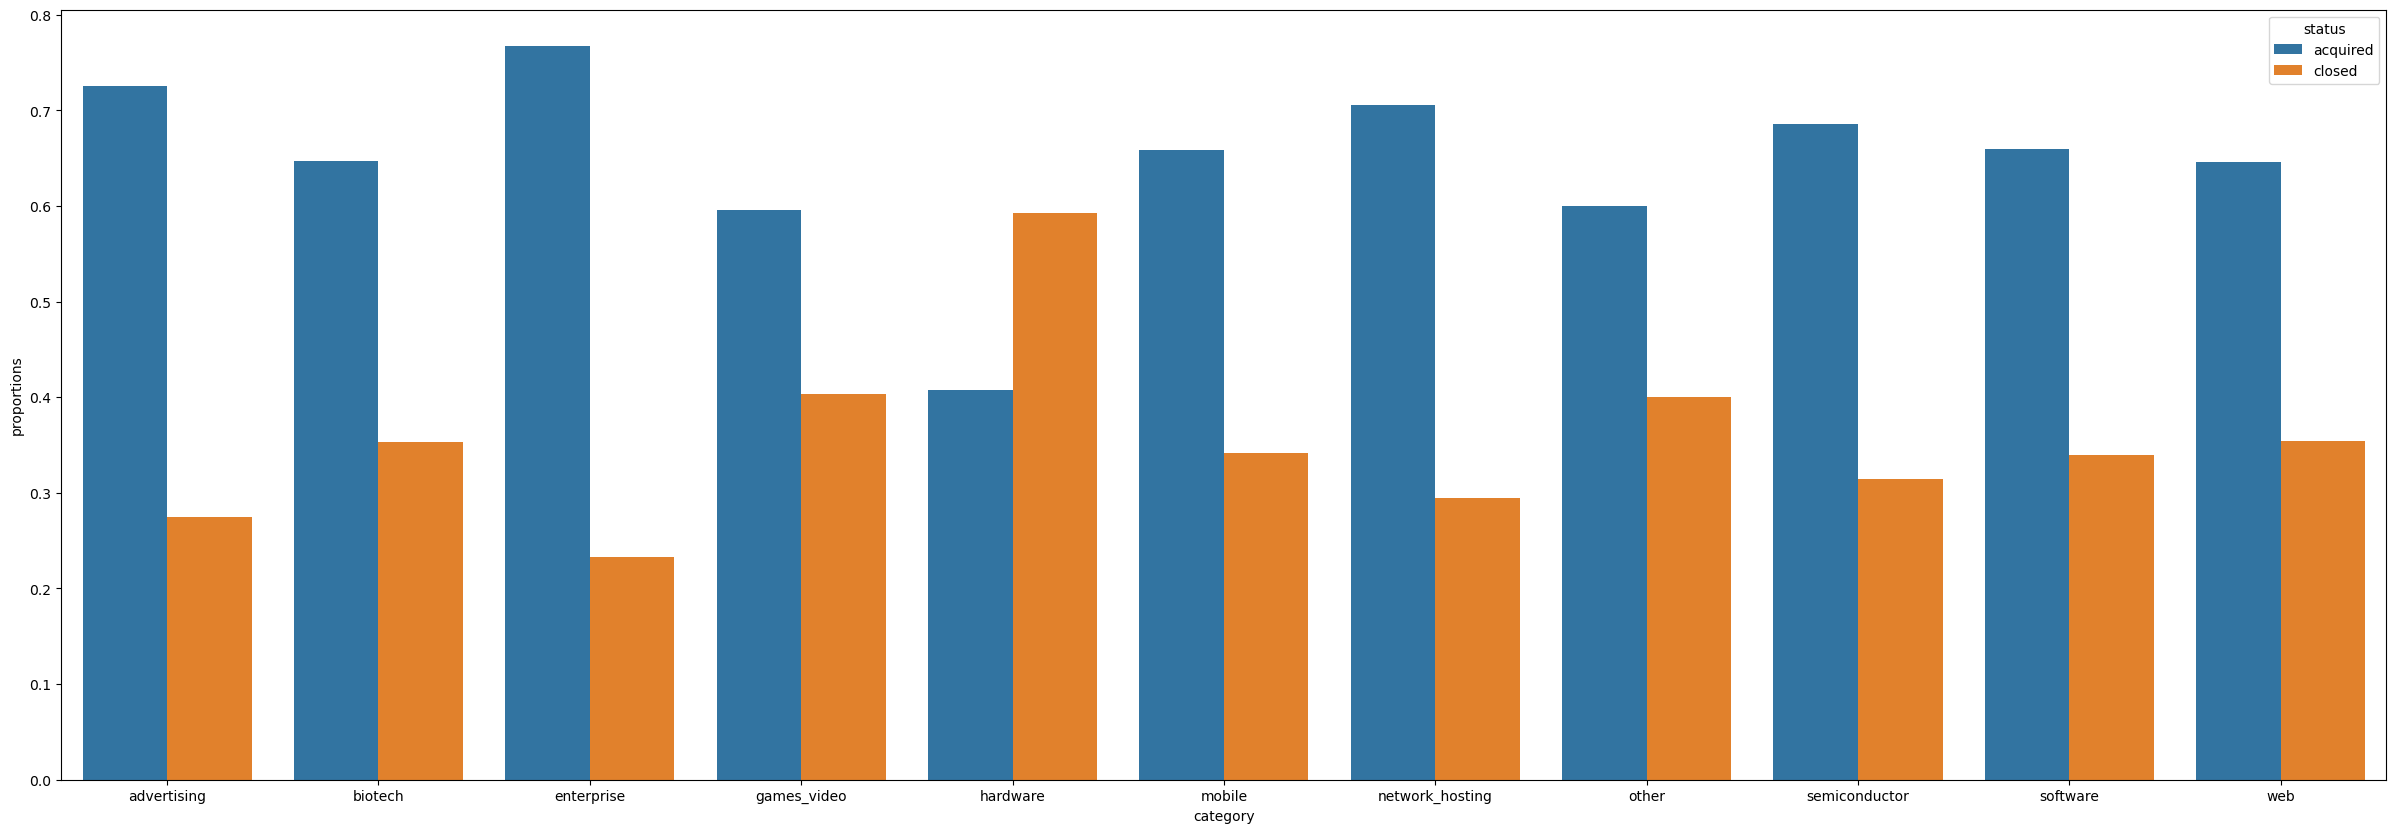

In [17]:
fig, ax = plt.subplots(figsize = (30,10))

prop_df = data.groupby(['category','status']).size().reset_index(name = 'counts')
prop_df['proportions'] = prop_df['counts'] / prop_df.groupby('category')['counts'].transform('sum')

sns.barplot(data = prop_df, x = 'category', y = 'proportions', hue = 'status')


Text(0.5, 1.0, 'Category wise evolution of startups')

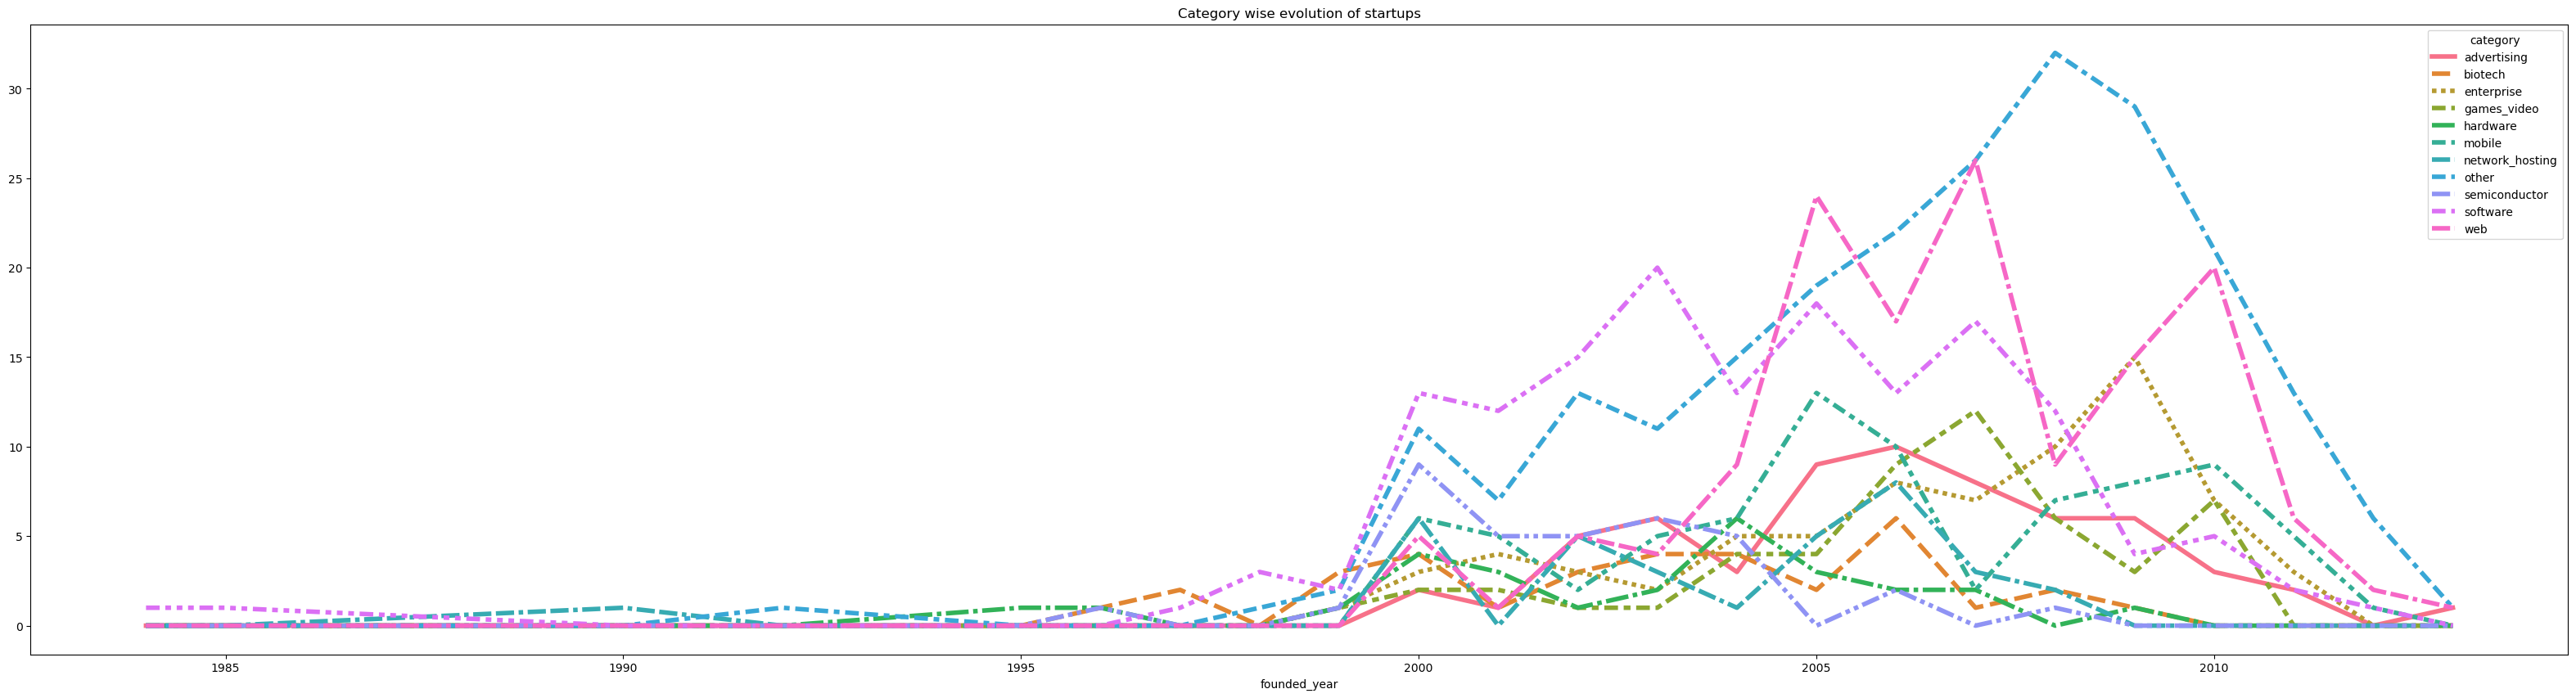

In [25]:
data['founded_year'] = pd.to_datetime(data['founded_at'], errors='coerce').dt.year

cat_year = pd.crosstab(index = data['founded_year'], columns = data['category'])

fig, ax = plt.subplots(figsize = (40,10))
sns.lineplot(data = cat_year, lw = 4)
plt.title('Category wise evolution of startups')


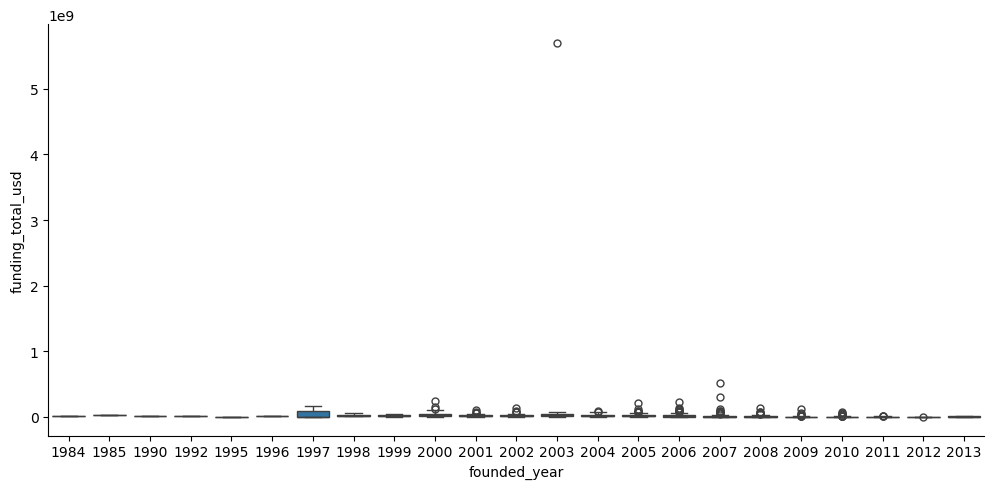

In [27]:
sns.catplot(
    data = data,
    x = 'founded_year',
    y = 'funding_total_usd',
    kind = 'box',
    height = 5,
    aspect = 2,
    order = [
        '1984','1985','1990','1992','1995',
        '1996','1997','1998','1999','2000',
        '2001','2002','2003','2004','2005',
        '2006','2007','2008','2009','2010',
        '2011','2012','2013'
    ]
)


<Axes: xlabel='variable', ylabel='count'>

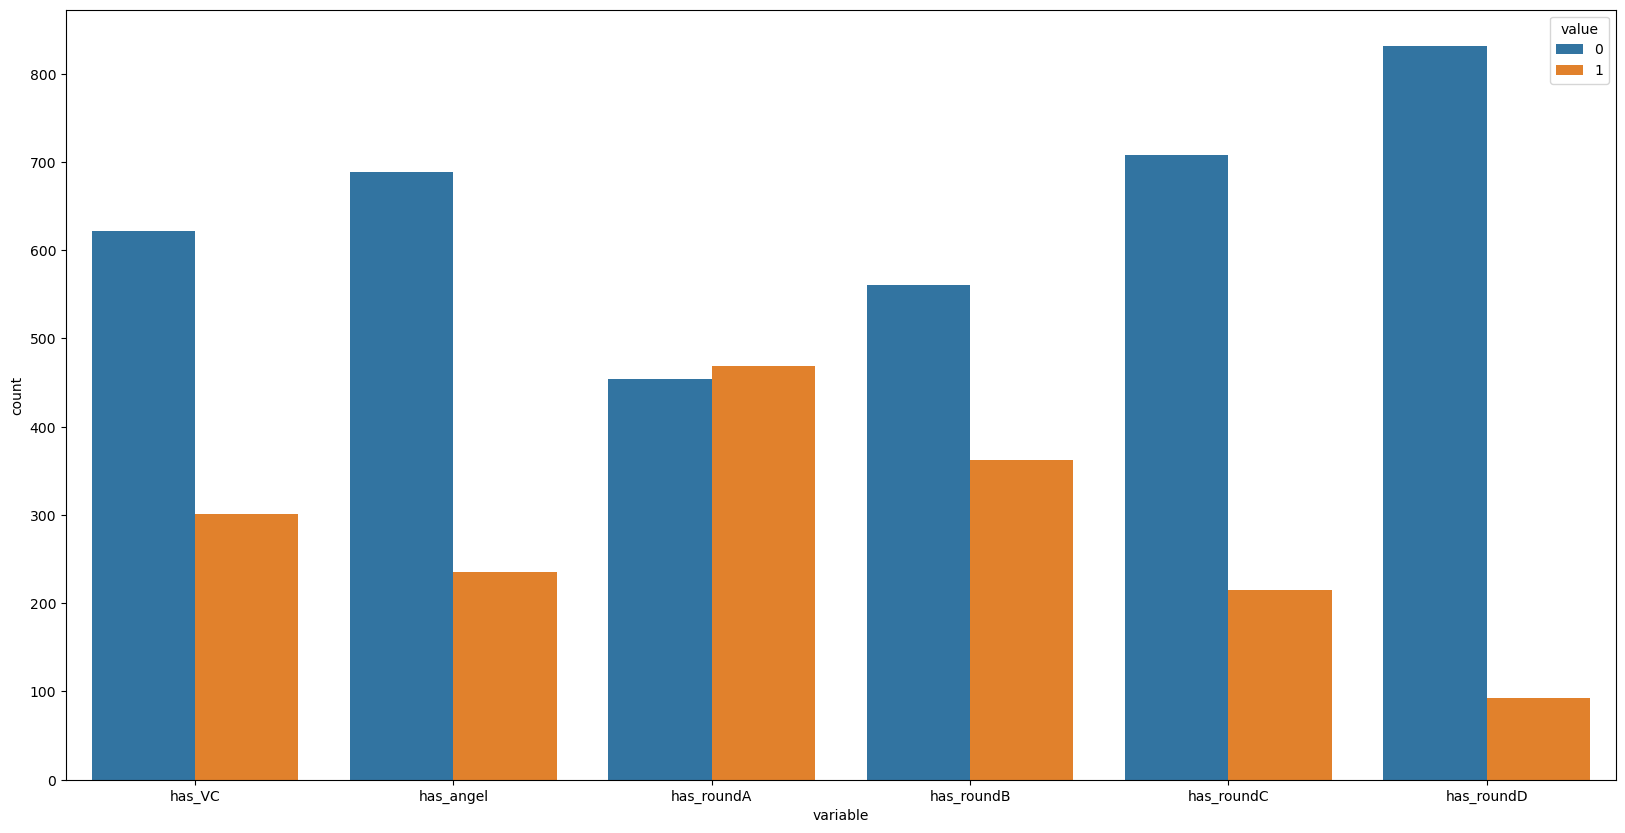

In [39]:
fig, ax = plt.subplots(figsize = (20,10))

d = data[['has_VC','has_angel','has_roundA','has_roundB','has_roundC','has_roundD']]

sns.countplot(data = pd.melt(d), x = 'variable', hue = 'value')


In [41]:
data.describe( include = [ 'float64', 'int64'] )

,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,is_CA,is_NY,is_MA,is_TX,is_otherstate,is_software,is_web,is_mobile,is_enterprise,is_advertising,is_gamesvideo,is_ecommerce,is_biotech,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,9.230000e+02,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.00000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,2.541975e+07,1.841820,0.527627,0.114843,0.089924,0.045504,0.221018,0.165764,0.156013,0.08559,0.079090,0.067172,0.056338,0.027086,0.036836,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,1.896344e+08,1.322632,0.499507,0.319005,0.286228,0.208519,0.415158,0.372070,0.363064,0.27991,0.270025,0.250456,0.230698,0.162421,0.188462,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,1.100000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,2.725000e+06,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,1.000000e+07,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,2.472500e+07,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,5.700000e+09,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


<Axes: >

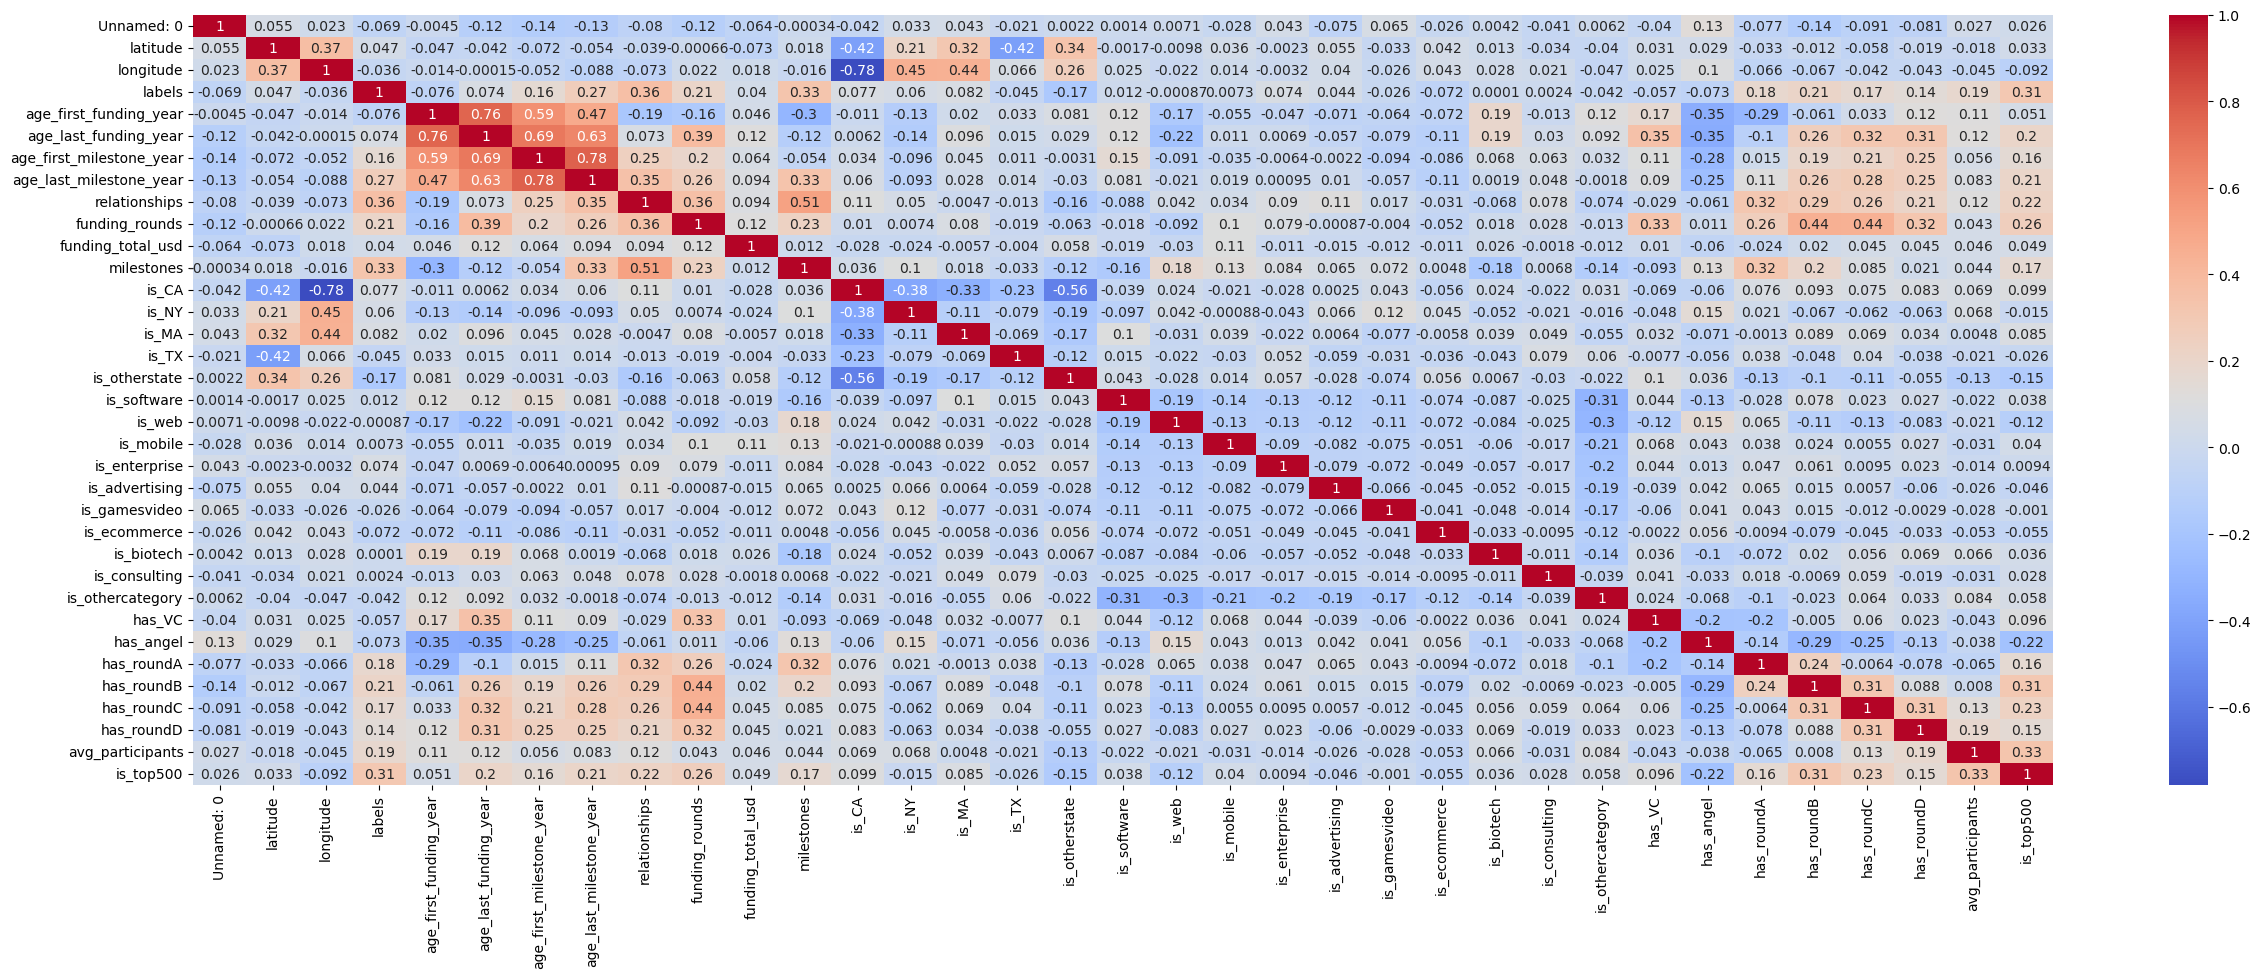

In [43]:
fig, ax = plt.subplots(figsize = (30,10))

corr = data.select_dtypes(include = ['int64','float64']).corr()

sns.heatmap(corr, cmap = 'coolwarm', annot = True)


In [45]:
data = data.drop(columns = ['Unnamed: 0', 'id'], errors = 'ignore')

In [47]:
data['founded_year'] = pd.to_datetime(
    data['founded_at'], errors='coerce'
).dt.year


In [49]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
data[num_cols] = data[num_cols].fillna(0)


In [51]:
data['is_CA'] = (data['State'] == 'CA').astype(int)
data['is_NY'] = (data['State'] == 'NY').astype(int)
data['is_MA'] = (data['State'] == 'MA').astype(int)
data['is_TX'] = (data['State'] == 'TX').astype(int)
data['is_otherstate'] = (~data['State'].isin(['CA','NY','MA','TX'])).astype(int)


In [53]:
data['is_software'] = (data['category'] == 'software').astype(int)
data['is_web'] = (data['category'] == 'web').astype(int)
data['is_mobile'] = (data['category'] == 'mobile').astype(int)
data['is_enterprise'] = (data['category'] == 'enterprise').astype(int)
data['is_advertising'] = (data['category'] == 'advertising').astype(int)
data['is_gamesvideo'] = (data['category'] == 'games_video').astype(int)
data['is_ecommerce'] = (data['category'] == 'ecommerce').astype(int)
data['is_biotech'] = (data['category'] == 'biotech').astype(int)
data['is_consulting'] = (data['category'] == 'consulting').astype(int)
data['is_othercategory'] = (
    ~data['category'].isin([
        'software','web','mobile','enterprise',
        'advertising','games_video','ecommerce',
        'biotech','consulting'
    ])
).astype(int)


In [57]:
round_cols = [
    'has_VC','has_angel',
    'has_roundA','has_roundB',
    'has_roundC','has_roundD'
]

data[round_cols] = data[round_cols].fillna(0).astype(int)


In [59]:
corr_df = data.select_dtypes(include=['int64','float64'])


In [61]:
corr = corr_df.corr()


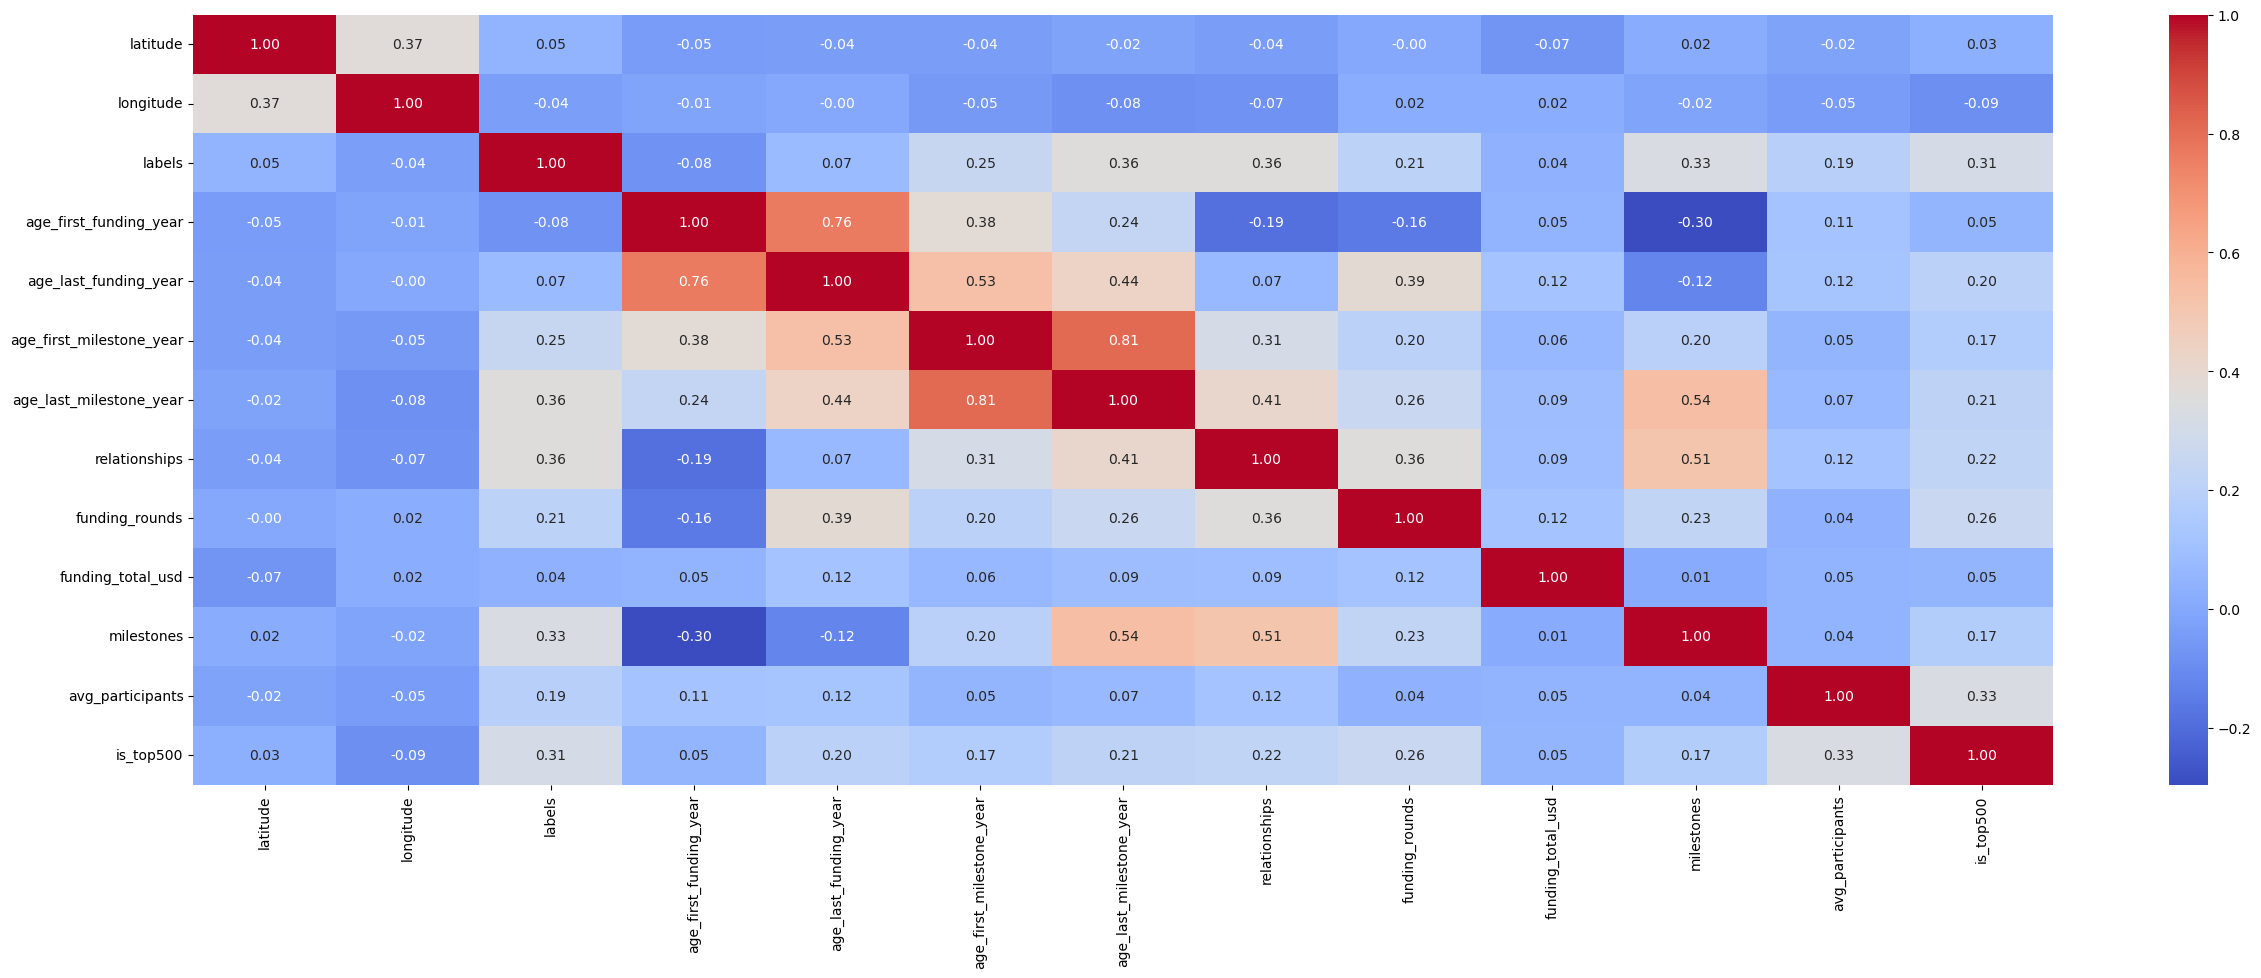

In [63]:
fig, ax = plt.subplots(figsize = (30,10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.show()


In [67]:
print(data['state_code'].equals(data['state_code.1']))


False


In [69]:
df = data.loc[data['state_code'] != data['state_code.1']]
df.style.set_properties(**{'background-color': 'yellow'}, subset=['state_code','state_code.1'])

,state_code,latitude,longitude,zip_code,city,Unnamed: 6,name,labels,founded_at,closed_at,first_funding_at,last_funding_at,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,funding_total_usd,milestones,state_code.1,is_CA,is_NY,is_MA,is_TX,is_otherstate,category_code,is_software,is_web,is_mobile,is_enterprise,is_advertising,is_gamesvideo,is_ecommerce,is_biotech,is_consulting,is_othercategory,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status,State,category,founded_year
515,CA,37.451124,-122.166264,94025,Menlo Park,nan,Cuil,0,1/1/2005,9/1/2010,3/1/2007,4/15/2008,2.161600,3.287700,3.498600,7.690400,13,2,33000000,4,nan,1,0,0,0,0,search,0,0,0,0,0,0,0,0,0,1,c:856,0,0,1,1,0,0,2.500000,1,closed,CA,other,2005


In [71]:
state = data['state_code'].value_counts().to_frame(name='count')
state['proportion'] = state['count'] / state['count'].sum() * 100
state


,count,proportion
state_code,,
CA,488,52.871073
NY,106,11.484290
MA,83,8.992416
TX,42,4.550379
WA,42,4.550379
CO,19,2.058505
IL,18,1.950163
PA,17,1.841820
VA,13,1.408451


In [73]:
data = data.drop(
    [
        'category_code',
        'is_software',
        'is_web',
        'is_mobile',
        'is_enterprise',
        'is_advertising',
        'is_gamesvideo',
        'is_ecommerce',
        'is_biotech',
        'is_consulting',
        'is_othercategory'
    ],
    axis = 1
)


In [79]:
feature_cols = [
    'age_first_funding_year',
    'age_last_funding_year',
    'age_first_milestone_year',
    'age_last_milestone_year',
    'relationships',
    'funding_rounds',
    'funding_total_usd',
    'milestones',
    'avg_participants'
]

X = data[feature_cols]


In [81]:
X.head()
X.shape
X.isna().sum()


age_first_funding_year      0
age_last_funding_year       0
age_first_milestone_year    0
age_last_milestone_year     0
relationships               0
funding_rounds              0
funding_total_usd           0
milestones                  0
avg_participants            0
dtype: int64

In [83]:
y = data['labels']


In [87]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.3,
    random_state = 0,
    stratify = y
)
# applying Random Forest classifier
model = RandomForestClassifier()
model.fit(x_train, y_train)

y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)

# checking accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

test_acc = accuracy_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)

print('test_acc :', test_acc)
print('train_acc :', train_acc)


test_acc : 0.8158844765342961
train_acc : 1.0


In [89]:
model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 10,
    min_samples_leaf = 5,
    random_state = 0
)


In [91]:
model.fit(x_train, y_train)

y_pred_test = model.predict(x_test)
y_pred_train = model.predict(x_train)

print('test_acc :', accuracy_score(y_test, y_pred_test))
print('train_acc :', accuracy_score(y_train, y_pred_train))


test_acc : 0.7978339350180506
train_acc : 0.8730650154798761


In [93]:
print(classification_report(y_test, y_pred_test))
confusion_matrix(y_test, y_pred_test)


              precision    recall  f1-score   support

           0       0.78      0.60      0.68        98
           1       0.81      0.91      0.85       179

    accuracy                           0.80       277
   macro avg       0.79      0.75      0.77       277
weighted avg       0.80      0.80      0.79       277



array([[ 59,  39],
       [ 17, 162]], dtype=int64)

In [95]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}


In [97]:
rf = RandomForestClassifier(
    random_state = 0,
    class_weight = 'balanced'
)


In [99]:
grid = GridSearchCV(
    estimator = rf,
    param_grid = param_grid,
    scoring = 'f1_weighted',
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

grid.fit(x_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              random_state=0),
             n_jobs=-1,
             param_grid={'max_depth': [8, 10, 12],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200]},
             scoring='f1_weighted', verbose=1)

In [101]:
grid.best_params_


{'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 100}

In [103]:
best_model = grid.best_estimator_

best_model.fit(x_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, random_state=0)

In [105]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_test = best_model.predict(x_test)
y_pred_train = best_model.predict(x_train)

print('Train acc:', accuracy_score(y_train, y_pred_train))
print('Test acc :', accuracy_score(y_test, y_pred_test))

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_test))

confusion_matrix(y_test, y_pred_test)


Train acc: 0.9427244582043344
Test acc : 0.8050541516245487

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.66      0.71        98
           1       0.83      0.88      0.85       179

    accuracy                           0.81       277
   macro avg       0.79      0.77      0.78       277
weighted avg       0.80      0.81      0.80       277



array([[ 65,  33],
       [ 21, 158]], dtype=int64)

In [107]:
import joblib
joblib.dump(best_model, 'startup_rf_model.pkl')


['startup_rf_model.pkl']

In [109]:
model = joblib.load('startup_rf_model.pkl')


In [111]:
type(model)


sklearn.ensemble._forest.RandomForestClassifier

In [113]:
feature_cols = [
    'age_first_funding_year',
    'age_last_funding_year',
    'age_first_milestone_year',
    'age_last_milestone_year',
    'relationships',
    'funding_rounds',
    'funding_total_usd',
    'milestones',
    'avg_participants'
]


In [115]:
X_test_model = x_test[feature_cols]

y_pred = model.predict(X_test_model)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Test accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)


Test accuracy: 0.8050541516245487

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.66      0.71        98
           1       0.83      0.88      0.85       179

    accuracy                           0.81       277
   macro avg       0.79      0.77      0.78       277
weighted avg       0.80      0.81      0.80       277



array([[ 65,  33],
       [ 21, 158]], dtype=int64)

In [117]:
sample_input = [[
    2.1,    # age_first_funding_year
    4.0,    # age_last_funding_year
    1.5,    # age_first_milestone_year
    3.2,    # age_last_milestone_year
    8,      # relationships
    3,      # funding_rounds
    12000000, # funding_total_usd
    4,      # milestones
    5       # avg_participants
]]

prediction = model.predict(sample_input)[0]
probability = model.predict_proba(sample_input)[0][1]

print('Prediction:', 'Success' if prediction == 1 else 'Failure')
print('Success probability:', probability)


Prediction: Success
Success probability: 0.5811554760908823


C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [119]:
sample_1 = [[
    1.2,     # age_first_funding_year
    3.5,     # age_last_funding_year
    0.8,     # age_first_milestone_year
    2.5,     # age_last_milestone_year
    15,      # relationships
    4,       # funding_rounds
    25000000,# funding_total_usd
    6,       # milestones
    7        # avg_participants
]]


In [121]:
sample_2 = [[
    5.5,     # age_first_funding_year
    7.0,     # age_last_funding_year
    4.8,     # age_first_milestone_year
    6.2,     # age_last_milestone_year
    2,       # relationships
    1,       # funding_rounds
    150000,  # funding_total_usd
    1,       # milestones
    1        # avg_participants
]]


In [123]:
sample_3 = [[
    2.8,     # age_first_funding_year
    4.5,     # age_last_funding_year
    2.0,     # age_first_milestone_year
    3.8,     # age_last_milestone_year
    6,       # relationships
    2,       # funding_rounds
    4000000, # funding_total_usd
    3,       # milestones
    3        # avg_participants
]]


In [125]:
for i, sample in enumerate([sample_1, sample_2, sample_3], 1):
    pred = model.predict(sample)[0]
    prob = model.predict_proba(sample)[0][1]
    print(f"Sample {i} →", "Success" if pred==1 else "Failure", "| Prob:", round(prob, 3))


Sample 1 → Success | Prob: 0.793
Sample 2 → Success | Prob: 0.617
Sample 3 → Success | Prob: 0.602


C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\donga\anaconda3\Lib\site-packages\sklearn\base.py:4

In [127]:
for sample in [sample_1, sample_2, sample_3]:
    df = pd.DataFrame(sample, columns=feature_cols)
    prob = model.predict_proba(df)[0][1]
    pred = 1 if prob >= 0.7 else 0
    print("Success" if pred else "Failure", "| Prob:", round(prob, 3))


Success | Prob: 0.793
Failure | Prob: 0.617
Failure | Prob: 0.602


In [149]:
threshold = 0.65

df = pd.DataFrame(sample_2, columns=feature_cols)
prob = model.predict_proba(df)[0][1]
decision = "success" if prob >= threshold * 100 else "failure"

percen = prob * 100
print(
    f"The startup has { percen:.2f}% chance of success, "
    f"likely to be a {decision}."
)


The startup has 61.67% chance of success, likely to be a failure.
